In [8]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
import numpy as np

In [10]:
from bayesgpt.simulators.model_family import NestedModelFamily
from bayesgpt.simulators.benchmarks.ddms.ddm import DDM
from bayesgpt.simulators.benchmarks.ddms.ddm_priors import ddm_baseline_priors, ddm_full_priors

In [11]:
intrinsic_parameters = ['v', "a", "tau", "s_v", "s_tau"]

In [12]:
ddm_family_auto = NestedModelFamily(
    name="DDM",
    model=DDM(),
    prior_fun=ddm_baseline_priors(),
    mask_randomizer_kwargs=dict(free_intrinsics=intrinsic_parameters, fixed_intrinsics=[], fixed_values={})
)

In [13]:
design_config = {
    "1": intrinsic_parameters,
    "u_1": ['v', "a", "tau", "s_v"],
    "u_2": ['v', "a", "tau"],
    "u_1:u_2": ['v', "a"]
}

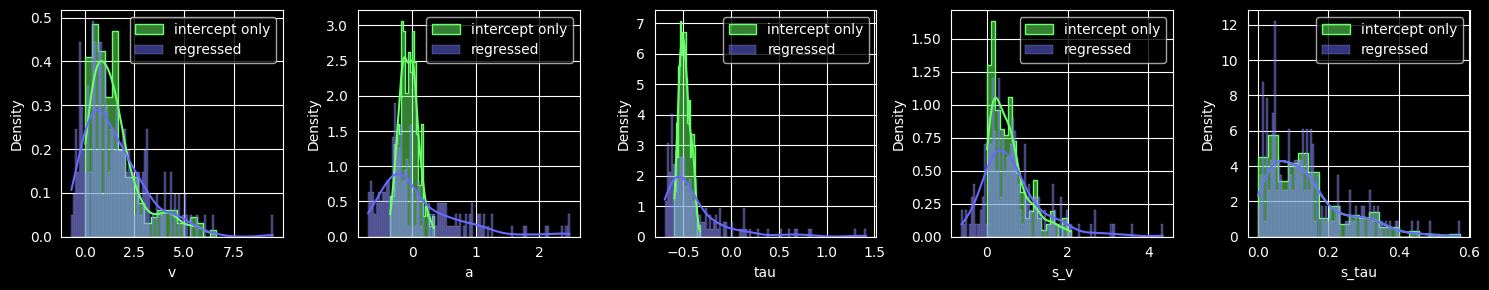

In [14]:
auto_priors = ddm_family_auto.check_regressed_priors(
    design_config=design_config,
)

In [6]:
ddm_family_full = NestedModelFamily(
    name="DDM",
    model=DDM(),
    prior_fun=ddm_full_priors(),
    mask_randomizer_kwargs=dict(free_intrinsics=intrinsic_parameters, fixed_intrinsics=[], fixed_values={})
)

In [13]:
auto_samples = ddm_family_auto.batch_sample(
    min_num_obs=500,
    max_num_obs=1000,
    min_num_regressors=0,
    max_num_regressors=2,
    batch_size=10,
)

In [14]:
full_samples = ddm_family_full.batch_sample(
    min_num_obs=500,
    max_num_obs=1000,
    min_num_regressors=0,
    max_num_regressors=2,
    batch_size=10,
)

In [15]:
for k, v in auto_samples.items():
    if isinstance(v, np.ndarray):
        print(k, v.shape)
    elif isinstance(v, dict):
        print(k, v.keys())
    elif isinstance(v, list):
        print(k, len(v))
    else:
        print(k, v)

model_names 10
design_configs 10
design_matrices (10, 510, 7)
param_masks (10, 35)
param_matrices (10, 35)
sim_data dict_keys(['rts', 'choices'])
regressor_masks (10, 7)
discrete_masks (10, 3)
num_obs (10, 1)
num_regressors (10, 1)
max_num_regressors 2
max_num_categories 3


In [16]:
auto_samples["num_obs"]

array([[510.],
       [510.],
       [510.],
       [510.],
       [510.],
       [510.],
       [510.],
       [510.],
       [510.],
       [510.]])

In [12]:
auto_samples["sim_data"]["rts"].shape

(10, 778, 1)